In [1]:
import pandas as pd
import numpy as np
import datetime
import joblib

In [2]:
df = pd.read_csv("mongo_full_data.csv")

C:\Users\Flipshope\AppData\Local\Temp\ipykernel_21812\1713509492.py:1: DtypeWarning: Columns (1,2,5,12,14,28,29,30,35,40,45,46,47,48,56,60,61,63,64,69,70,71,73,74,75) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mongo_full_data.csv")


In [3]:
print(df.columns.tolist())

['_id', 'pid', 'sid', 'price', 'is_deal', 'category', 'sub_cat_id', 'title', 'rating', 'rating_count', 'imgurl', 'mrp', 'data', 'time', 'uid', 'last_lowest_price', 'ma_15', 'ma_3', 'ma_30', 'ma_7', 'median', 'day_percent_30', 'day_percent_90', 'drop_median', 'drop_p20', 'pseudo_score', 'is_deal_pseudo', 'min', 'Time', 'active', 'brand', 'count', 'data_updated_validated', 'deal_type', 'discount', 'id', 'inStock', 'instock', 'is_a_deal', 'old_price', 'old_price_time', 'p20', 'score', 'sent', 'current_price', 'next_deal_check_time', 'aff_url', 'graph_data', 'inserted_at', 'isSent_app', 'isSent_app_V2', 'isSent_telegram', 'is_NotificationSent', 'is_NotificationSent_V2', 'is_deal_2', 'mapped', 'reactions', 'tbd_deal_active', 'tbd_deal_type', 'type', 'updated_at', 'isExpired', 'score_2', 'cat', 'deal_queue_id', 'score_old', 'sub_category', 'tel_send', 'sent_notification', 'sent_notification_time', 'color', 'latestPrice', 'stock', 'text', 'last_sent_time', ' graph_data', 'priority']


In [4]:
df_required = df[
    [
        "sid","pid","price",
        "category",
        "data"
    ]
].copy()

print(df_required.shape)

(628511, 5)


In [5]:
print(type(df_required["data"].iloc[0]))


<class 'str'>


In [6]:
print(df_required.columns)

Index(['sid', 'pid', 'price', 'category', 'data'], dtype='object')


In [7]:
import ast

sample = ast.literal_eval(df_required["data"].iloc[0])

print(type(sample))
print(list(sample.items())[:-1])

<class 'dict'>
[('2024-01-11', {'0': 4222.0, '1': 5131.0}), ('2024-01-12', {'0': 4222.0, '1': 5131.0}), ('2024-01-13', {'0': 5131.0, '1': 5196.0}), ('2024-01-14', {'0': 5131.0, '1': 5196.0}), ('2024-01-15', {'0': 5131.0, '1': 5196.0}), ('2024-01-16', {'0': 5131.0, '1': 5391.0}), ('2024-01-17', {'0': 5326.0, '1': 5391.0}), ('2024-01-18', {'0': 5326.0, '1': 5391.0}), ('2024-01-19', {'0': 4871.0, '1': 5326.0}), ('2024-01-20', {'0': 4871.0, '1': 4871.0}), ('2024-01-21', {'0': 4871.0, '1': 4936.0}), ('2024-01-22', {'0': 5326.0, '1': 5391.0}), ('2024-01-23', {'0': 5326.0, '1': 5326.0}), ('2024-01-25', {'0': 5326.0, '1': 5391.0}), ('2024-01-26', {'0': 4287.0, '1': 4417.0}), ('2024-01-27', {'0': 4287.0, '1': 4352.0}), ('2024-01-28', {'0': 4287.0, '1': 4352.0}), ('2024-01-29', {'0': 4287.0, '1': 5326.0}), ('2024-01-30', {'0': 4352.0, '1': 5391.0}), ('2024-01-31', {'0': 4676.0, '1': 5391.0}), ('2024-02-01', {'0': 4676.0, '1': 4741.0}), ('2024-02-02', {'0': 4676.0, '1': 4741.0}), ('2024-02-03', {

In [8]:
print(type(df["data"].iloc[0]))

<class 'str'>


In [9]:
print(df_required["data"].isna().sum())
print(df_required["category"].isna().sum())
print(df_required["price"].isna().sum())

print(len(df_required))

96363
3050
3
628511


In [10]:
# Drop rows where 'data', 'category', or 'price' are null
df_required = df_required.dropna(subset=['data', 'category', 'price'])

# Verify the result
print(f"Number of rows after dropping nulls: {len(df_required)}")
print("Missing values count:")
print(df_required[['data', 'category', 'price']].isna().sum())

Number of rows after dropping nulls: 532148
Missing values count:
data        0
category    0
price       0
dtype: int64


In [13]:
import ast
import datetime
import numpy as np
import pandas as pd


print("Rows to process:", len(df_required))

def calculate_180d_anchors_cleaned(graph_data):

    # Convert string -> dict
    if isinstance(graph_data, str):
        try:
            graph_data = ast.literal_eval(graph_data)
        except Exception:
            return {
                "median_180": 0.0,
                "min_180": 0.0,
                "flash_factor": 0.0,
                "valid": False,
            }

    if not isinstance(graph_data, dict) or not graph_data:
        return {
            "median_180": 0.0,
            "min_180": 0.0,
            "flash_factor": 0.0,
            "valid": False,
        }

    try:
        all_dates = [
            datetime.datetime.strptime(
                d,
                "%Y-%m-%d"
            )
            for d in graph_data.keys()
        ]

        latest_date = max(all_dates)

    except Exception:
        return {
            "median_180": 0.0,
            "min_180": 0.0,
            "flash_factor": 0.0,
            "valid": False,
        }

    cutoff_date = latest_date - datetime.timedelta(days=180)

    prices_low = []
    prices_high = []

    for date_str, values in graph_data.items():

        try:
            price_date = datetime.datetime.strptime(
                date_str,
                "%Y-%m-%d"
            )

            if (
                cutoff_date <= price_date < latest_date
                and isinstance(values, dict)
            ):

                low_p = float(values.get("0", 0))

                high_p = float(
                    values.get("1", low_p)
                )

                if high_p <= 0:
                    high_p = low_p

                if low_p > 0:
                    prices_low.append(low_p)
                    prices_high.append(high_p)

        except Exception:
            continue

    if len(prices_low) < 3:
        return {
            "median_180": 0.0,
            "min_180": 0.0,
            "flash_factor": 0.0,
            "valid": False,
        }

    prices_low = np.array(prices_low)
    prices_high = np.array(prices_high)

    hist_median = np.median(prices_low)

    clean_floor = np.min(prices_low)

    intraday_spreads = (
        prices_high - prices_low
    ) / prices_high

    flash_factor = min(
        np.mean(intraday_spreads) / 0.30,
        1.0
    )

    return {
        "median_180": float(hist_median),
        "min_180": float(clean_floor),
        "flash_factor": float(flash_factor),
        "valid": True,
    }


# TEST FIRST
sample = df_required.head(1000)

anchor_test = pd.DataFrame(
    sample["data"]
    .apply(calculate_180d_anchors_cleaned)
    .tolist()
)

print(anchor_test["valid"].value_counts())

# FULL BATCH PROCESSING
from tqdm import tqdm

batch_size = 20000

for start in tqdm(
    range(0, len(df_required), batch_size)
):

    end = min(
        start + batch_size,
        len(df_required)
    )

    batch = df_required.iloc[start:end]

    anchor_batch = pd.DataFrame(
        batch["data"]
        .apply(calculate_180d_anchors_cleaned)
        .tolist()
    )

    anchor_batch.to_parquet(
        f"anchor_batch_{start}_{end}.parquet",
        index=False
    )

    print(
        f"Saved batch {start:,} -> {end:,}"
    )

print("All batches saved.")

Rows to process: 532148


KeyboardInterrupt: 

In [ ]:
import glob
import pandas as pd

# 1. Load your original CSV (the source of truth)
# Replace 'your_data.csv' with the actual file name of your source
df_source = pd.read_csv('mongo_full_data.csv') 

# 2. Get the list of all parquet files
files = sorted(glob.glob("anchor_batch_*.parquet"))

# 3. Load all parquet files into a list first
dfs = [pd.read_parquet(f) for f in files]
anchor_df = pd.concat(dfs, ignore_index=True)

# 4. CRITICAL: Merge instead of assigning values
# This matches the features to the IDs from your source file automatically.
# It will discard any rows in the parquet files that don't match the source.
df_final = pd.merge(
    df_source[['sid', 'pid']], # Only take the IDs from the source
    anchor_df,                 # Your calculated features
    left_index=True,           # This assumes your parquet batching preserved order
    right_index=True,          # If order is NOT preserved, use on=['sid', 'pid']
    how='inner'
)

print(f"Alignment successful. New shape: {df_final.shape}")

C:\Users\Flipshope\AppData\Local\Temp\ipykernel_17636\3873105580.py:6: DtypeWarning: Columns (1,2,5,12,14,28,29,30,35,40,45,46,47,48,56,60,61,63,64,69,70,71,73,74,75) have mixed types. Specify dtype option on import or set low_memory=False.
  df_source = pd.read_csv('mongo_full_data.csv')


Alignment successful. New shape: (628511, 8)


In [ ]:
import glob
import pandas as pd

files = sorted(glob.glob("anchor_batch_*.parquet"))

anchor_df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print(anchor_df.shape)
print(anchor_df["valid"].value_counts())

(690659, 6)
valid
True     592480
False     98179
Name: count, dtype: int64


In [ ]:
df_required = pd.concat(
    [
        df_required.reset_index(drop=True),
        anchor_df.reset_index(drop=True)
    ],
    axis=1
)

print(df_required.shape)

(690659, 11)


In [ ]:
print(df_required.shape)
print(df_required.columns.tolist())

(690659, 11)
['sid', 'pid', 'price', 'category', 'data', 'median_180', 'min_180', 'flash_factor', 'valid', 'sid', 'pid']


In [ ]:
import glob

files = sorted(glob.glob("anchor_batch_*.parquet"))

print("Total files:", len(files))

for f in files:
    print(f)

Total files: 34
anchor_batch_0_20000.parquet
anchor_batch_0_50000.parquet
anchor_batch_100000_120000.parquet
anchor_batch_120000_140000.parquet
anchor_batch_140000_160000.parquet
anchor_batch_160000_180000.parquet
anchor_batch_180000_200000.parquet
anchor_batch_200000_220000.parquet
anchor_batch_20000_40000.parquet
anchor_batch_220000_240000.parquet
anchor_batch_240000_260000.parquet
anchor_batch_260000_280000.parquet
anchor_batch_280000_300000.parquet
anchor_batch_300000_320000.parquet
anchor_batch_320000_340000.parquet
anchor_batch_340000_360000.parquet
anchor_batch_360000_380000.parquet
anchor_batch_380000_400000.parquet
anchor_batch_400000_420000.parquet
anchor_batch_40000_60000.parquet
anchor_batch_420000_440000.parquet
anchor_batch_440000_460000.parquet
anchor_batch_460000_480000.parquet
anchor_batch_480000_500000.parquet
anchor_batch_500000_520000.parquet
anchor_batch_520000_532148.parquet
anchor_batch_520000_540000.parquet
anchor_batch_540000_560000.parquet
anchor_batch_560000_

In [ ]:
import glob
import pandas as pd

files = sorted(glob.glob("anchor_batch_*.parquet"))

files = [
    f for f in files
    if f != "anchor_batch_0_50000.parquet"
]

anchor_df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print(anchor_df.shape)
print(anchor_df.columns.tolist())


(640659, 6)
['median_180', 'min_180', 'flash_factor', 'valid', 'sid', 'pid']


In [ ]:
print(anchor_df["valid"].value_counts())

valid
True     542520
False     98139
Name: count, dtype: int64


In [ ]:
df_required = pd.concat(
    [
        df_required[["price", "category", "data"]].reset_index(drop=True),
        anchor_df.reset_index(drop=True)
    ],
    axis=1
)

print(df_required.shape)

(690659, 9)


In [ ]:
# Create clean base dataframe

df_base = df[
    ["price", "category", "data"]
].copy()

print("Before:", len(df_base))

df_base = df_base.dropna(
    subset=["price", "category", "data"]
).reset_index(drop=True)

print("After:", len(df_base))
df_base.shape
df_base.columns.to_list()

Before: 628511
After: 532148


['price', 'category', 'data']

In [ ]:
df_required = pd.concat(
    [
        df_base.reset_index(drop=True),
        anchor_df.reset_index(drop=True)
    ],
    axis=1
)




In [ ]:
print(df_required["valid"].value_counts())

valid
True     542520
False     98139
Name: count, dtype: int64


In [ ]:
print(df_required.shape)

print(
    df_required[
        [
            "median_180",
            "min_180",
            "flash_factor"
        ]
    ].describe()
)

(640659, 9)
          median_180       min_180   flash_factor
count  640659.000000  640659.00000  640659.000000
mean     1591.953067    1144.01800       0.041598
std      6880.797489    5110.54096       0.101246
min         0.000000       0.00000       0.000000
25%       199.000000     138.50000       0.000000
50%       579.000000     399.00000       0.006295
75%      1299.000000     923.00000       0.042704
max    989000.000000  989000.00000       1.000000


In [ ]:
# 1. Define your category logic dictionaries
category_avg_discount = {
    1: 45, 2: 35, 3: 40, 4: 30, 5: 30,
    6: 20, 7: 25, 8: 45, 9: 45, 10: 20,
    11: 40, 12: 25, 13: 25, 14: 45,
    15: 28, 16: 35, 17: 25
}

category_tolerance = {
    1: 3, 2: 2, 3: 4, 4: 2, 5: 3,
    6: 2, 7: 2, 8: 3, 9: 3, 10: 2,
    11: 4, 12: 1, 13: 1, 14: 3,
    15: 3, 16: 3, 17: 2
}

# 2. Clean and convert the category column
df_required["category"] = pd.to_numeric(df_required["category"], errors="coerce")
df_required = df_required.dropna(subset=["category"])
df_required["category"] = df_required["category"].astype(int)

# 3. Map the benchmarks
df_required["avg_category_discount"] = df_required["category"].map(category_avg_discount).fillna(25)
df_required["category_tolerance_val"] = df_required["category"].map(category_tolerance).fillna(2)

# 4. Calculate the target percentage
df_required["cat_target_pct"] = (
    (df_required["avg_category_discount"] - df_required["category_tolerance_val"]) / 100.0
)

print("Features successfully mapped to df_required.")

Features successfully mapped to df_required.


In [ ]:

def predict_pure_historical_deal_score(row):
    """Vectorized calculation mapping current price from its own historical landmarks.

    PRODUCTION PERFORMANCE & PENALTY UPDATE:
    - Enforces a strict 5% absolute minimum markdown guardrail.
    - Uses an integrated category performance ratio to scale deal variance.
    - CONTINUOUS SCALER: Smoothly slopes values between 60% and 100% of target.
    """
    current_price = float(row.get("price", 0))
    median_180 = float(row.get("median_180", 0))
    min_180 = float(row.get("min_180", 0))
    flash_factor = float(row.get("flash_factor", 0))
    
    # Read the pre-mapped vector target directly for lightning-fast lookups
    cat_target = float(row.get("cat_target_pct", 0.25))

    if not row.get("valid", False) or current_price <= 0 or median_180 <= 0:
        return 0

    # Hard Ceiling Filter: Today's price MUST beat its own standard median baseline
    if current_price >= median_180:
        return 0

    # Feature 1: Percentage markdown relative to its personal median
    distance_median = (median_180 - current_price) / median_180

    # Guardrail Check: Instantly reject float noise or near-zero adjustments
    # if distance_median < 0.05:
    #     return 0

    # Measure performance against category targets (Cap raw ratio at 2.0x outperformance)
    category_ratio = distance_median / cat_target
    clipped_category_ratio = min(max(category_ratio, 0.0), 2.0)

    # Feature 2: Proximity to historical minimum with logarithmic acceleration
    price_window = median_180 - min_180
    if price_window > 10:
        raw_ratio = (median_180 - current_price) / price_window
        proximity_min = 1.0 - np.exp(-5.0 * max(raw_ratio, 0.0))
        
        # Realistic Depth Damper
        depth_damper = min(distance_median / 0.20, 1.0) 
        proximity_min *= depth_damper
    else:
        proximity_min = 0.0 

    # Feature 3: Floor-Breaker Bonus (Extra credit for breaching the 5th percentile floor)
    if current_price < min_180 and min_180 > 0:
        floor_break_bonus = ((min_180 - current_price) / min_180) * 1.5
    else:
        floor_break_bonus = 0.0

    # Combine features using optimized weights
    combined_factor = (
        (0.40 * (clipped_category_ratio * 0.30))
        + (0.40 * proximity_min)
        + (0.20 * flash_factor)
        + floor_break_bonus
    )

    # Absolute Price Tier Multiplier
    if median_180 < 300:
        tier_multiplier = 0.85
    elif median_180 < 800:
        tier_multiplier = 0.95
    elif median_180 < 2000:
        tier_multiplier = 1.00
    elif median_180 < 5000:
        tier_multiplier = 1.05
    else:
        tier_multiplier = 1.10
    # Initialize the primed factor
    combined_factor_primed = combined_factor

    # =====================================================================
    # CONTINUOUS NATURAL CATEGORY RANGE SCALER
    # =====================================================================
    # If the product fails to hit its category markdown goal (category_ratio < 1.0),
    # scale it down smoothly over a realistic performance band.
    if category_ratio < 1.0:
        smooth_multiplier = max(
            0.40,
            category_ratio
        )

        combined_factor_primed *= smooth_multiplier

    # Special Guardrail: If today's price is within 10% of the historical minimum and meets
    # or exceeds the category average discount target, ensure it is guaranteed to be a
    # verified good deal (Score >= 700) by relaxing budget price tier penalties and setting a factor floor.
    if current_price <= min_180 * 1.10 and min_180 > 0 and category_ratio >= 1.0:
        tier_multiplier = max(tier_multiplier, 1.0)
        # combined_factor_primed = max(combined_factor_primed, 0.70)

    # Deep Discount Guardrails: If a product has an exceptionally deep markdown (>= 50%),
    # it is always considered a good deal (Score >= 700), bypassing low-price tier penalties.
    # For discounts >= 35%, we ease the low-price tier multiplier penalty.
    if distance_median >= 0.50:
        tier_multiplier = max(tier_multiplier, 1.0)
        # combined_factor_primed = max(combined_factor_primed, 0.70)
    elif distance_median >= 0.35:
        tier_multiplier = max(tier_multiplier, 0.85)

    # Apply absolute price tier constraints natively
    combined_factor_primed = combined_factor_primed * tier_multiplier

    # Final Scaling & Range Expansion
    raw_score = 1000 * (1 - np.exp(-combined_factor_primed * 2.0))

    return int(max(min(raw_score, 1000), 0))

In [ ]:
df_required["deal_score"] = df_required.apply(
    predict_pure_historical_deal_score,
    axis=1
)

In [ ]:
print(
    (df_required["deal_score"] > 0).sum()
)

print(
    df_required["deal_score"].describe()
)

print(
    df_required["deal_score"]
    .quantile([0.5,0.75,0.9,0.95,0.99])
)

304921
count    532148.000000
mean        463.448372
std         445.123968
min           0.000000
25%           0.000000
50%         469.000000
75%         954.000000
max         992.000000
Name: deal_score, dtype: float64
0.50    469.0
0.75    954.0
0.90    981.0
0.95    986.0
0.99    990.0
Name: deal_score, dtype: float64


In [ ]:
df_required["target"] = (
    df_required["deal_score"] >= 670
).astype(int)

In [ ]:
print(df_required["target"].value_counts())

target
0    291432
1    240716
Name: count, dtype: int64


In [ ]:
cols = [
    "price",
    "category",
    "data",
    "ma_7",
    "ma_30",
    "day_percent_90",
    "drop_p20"
]

df_base = df[cols].copy()

In [ ]:
valid_mask = (
    df["price"].notna() &
    df["category"].notna() &
    df["data"].notna()
)

print(valid_mask.sum())

532148


In [ ]:
df_base = df_base.loc[
    valid_mask
].reset_index(drop=True)

print(df_base.shape)

(532148, 7)


In [ ]:

print(anchor_df.shape)

(640659, 6)


In [ ]:
valid_mask = (
    df["price"].notna() &
    df["category"].notna() &
    df["data"].notna()
)


print(valid_mask.sum())

532148


In [ ]:
# 1. Create the mask specifically from df_base
valid_mask = (
    df_base["price"].notna() &
    df_base["category"].notna() &
    df_base["data"].notna()
)

# 2. Apply it to the same object
df_base = df_base.loc[valid_mask].reset_index(drop=True)

print(f"New shape of df_base: {df_base.shape}")

New shape of df_base: (532148, 7)


In [ ]:
# 1. Load your labeled data (the "Source of Truth")
df_labeled = pd.read_csv('unique_deals_sid_pid.csv') # Contains sid, pid, target

# 2. Define the columns you want to fetch from your DB
# Including the pre-calculated ma_15 and ma_30
db_features = ['sid', 'pid', 'price', 'category', 'data', 'ma_15', 'ma_30']

# 3. Fetch the data from the DB for all sids/pids in your CSV
# It is faster to query the DB in one batch rather than row-by-row
all_db_data = pd.read_csv('mongo_full_data.csv', usecols=db_features) 

# 4. Merge the labeled data with the database features
# This automatically fills in the features for every sid/pid in your CSV
training_df = pd.merge(df_labeled, all_db_data, on=['sid', 'pid'], how='left')

# 5. Handle any potential missing values
# If a specific sid/pid exists in your CSV but not in the DB, fill NaNs
training_df.fillna(0, inplace=True)

C:\Users\Flipshope\AppData\Local\Temp\ipykernel_17636\4173347699.py:10: DtypeWarning: Columns (1,2,5,12) have mixed types. Specify dtype option on import or set low_memory=False.
  all_db_data = pd.read_csv('mongo_full_data.csv', usecols=db_features)
C:\Users\Flipshope\AppData\Local\Temp\ipykernel_17636\4173347699.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  training_df.fillna(0, inplace=True)


In [ ]:
features = [
    "price",
    "median_180",
    "min_180",
    "flash_factor",
    # "cat_target_pct",
    # "ma_7","ma_30","day_percent_90","drop_p20"
]

print(df_required[features].isna().sum())

price           0
median_180      0
min_180         0
flash_factor    0
dtype: int64


In [ ]:
print("deal_score" in df_required.columns)
print("target" in df_required.columns)

True
True


In [ ]:
from sklearn.model_selection import train_test_split

X = df_required[features]
y = df_required["target"]
TEST_SIZE = 106430

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42
    
)

print(X_train.shape)
print(X_test.shape)



(425718, 4)
(106430, 4)


In [ ]:
print(len(features))
print(features)

4
['price', 'median_180', 'min_180', 'flash_factor']


In [ ]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 192579, number of negative: 233139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 425718, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.452363 -> initscore=-0.191128
[LightGBM] [Info] Start training from score -0.191128


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

for name, model in {
    "LightGBM": lgb_model,
    "XGBoost": xgb_model
}.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    print("\n", name)
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1       :", f1_score(y_test, pred))
    print("ROC_AUC  :", roc_auc_score(y_test, prob))


 LightGBM
Accuracy : 0.9894578596260453
Precision: 0.9907312694403273
Recall   : 0.9859152003656231
F1       : 0.9883173677634319
ROC_AUC  : 0.999617709789171

 XGBoost
Accuracy : 0.9894108803908672
Precision: 0.9904436005508492
Recall   : 0.9861021667324511
F1       : 0.9882681157157283
ROC_AUC  : 0.9996067525722805


In [ ]:
print(df_required["target"].value_counts(normalize=True))

target
0    0.547652
1    0.452348
Name: proportion, dtype: float64


In [ ]:
import joblib
joblib.dump(model, 'labeled2.pkl')
print("Model saved successfully.")

Model saved successfully.


In [ ]:
print(type(model))
print(model)



<class 'xgboost.sklearn.XGBClassifier'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


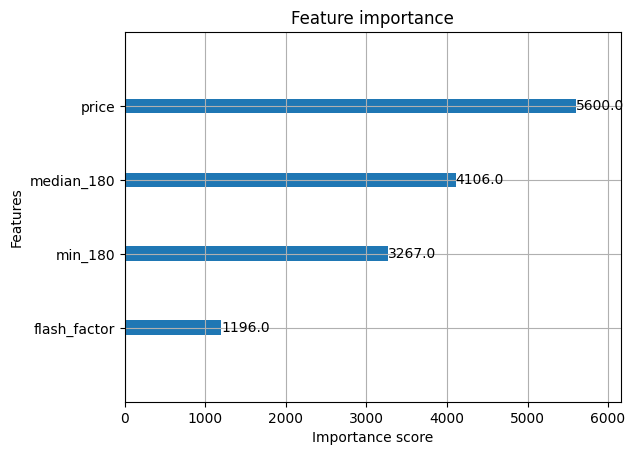

In [55]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.show()